In [1]:
# Fig 7A S1 LFP examples and summaries
# added SD and used filtered data

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import pickle
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import statistics
%matplotlib inline

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [ ]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [4]:
### load saved example data - BRC5_day2 - max response pad/cond=4
irec_depth_dict_file = os.path.join(data_dir, 'depth_dict_BRC5.pickle')
with open(irec_depth_dict_file, 'rb') as handle:
     irec_depth_dict = pickle.load(handle)

LFP_mean_pads_BRC5_plot_file = os.path.join(data_dir, 'LFP_mean_pads_BRC5_plot.npy')
lfp_mean_pads_plot = np.load(LFP_mean_pads_BRC5_plot_file)

LFP_sd_pads_BRC5_plot_file = os.path.join(data_dir, 'LFP_sd_pads_BRC5_plot.npy')
lfp_sd_pads_plot = np.load(LFP_sd_pads_BRC5_plot_file)

laser_samp_dir = os.path.join(data_dir, 'sync_samp')

In [5]:
# select channels by layer
chanid_l23 = irec_depth_dict['chanid_l23']
chanid_l4 = irec_depth_dict['chanid_l4']
chanid_l5 = irec_depth_dict['chanid_l5']
chanid_l6 = irec_depth_dict['chanid_l6']

# order channels by layer/depth
chanid_S1 = np.concatenate((chanid_l6, chanid_l5, chanid_l4, chanid_l23))
chanid_S1r = np.flip(chanid_S1) # reverse order of channels

In [ ]:
# load the laser time for each set 0 (saved again 25/12/10)

fs_laser = 30000
laser_samp_sync_sets = {}
laser_samp_async_sets = {}

for iset in range(1): # only load set 0

    sync_samp_file = 'sync_samp_set'+str(iset)+'.npy'
    async_samp_file = 'async_samp_set'+str(iset)+'.npy'

    laser_samp_sync_file = os.path.join(laser_samp_dir, sync_samp_file)
    laser_samp_async_file = os.path.join(laser_samp_dir, async_samp_file)

    laser_samp_sync = np.load(laser_samp_sync_file)
    laser_samp_async = np.load(laser_samp_async_file)

    laser_samp_sync_sets[iset] = laser_samp_sync
    laser_samp_async_sets[iset] = laser_samp_async


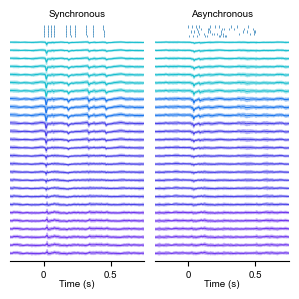

In [7]:
# plot example recording (Fig 5A) - sync and async, by depth, every 4 channels - add SD across trials
chanid_S1r_plot = chanid_S1r[2::4] # plot every 4 channels

fs_lfp= 2500
t_lfp = np.linspace(-1,2,int(3*fs_lfp)+1, endpoint=True)

sync_cond = 4 # plot pad 4
async_cond = 9

y_offset = 0
y_diff = -5000 # for every chan, add an offset

# plot trace0
laser_samp_sync = laser_samp_sync_sets[0]
laser_samp_async = laser_samp_async_sets[0]

fig, ax = plt.subplots(1,2, sharey= True,figsize = (3,3))

for i, ichan in enumerate(chanid_S1r_plot):
    ichan_lfp_sync  = lfp_mean_pads_plot[sync_cond,i,:]
    ichan_lfp_async = lfp_mean_pads_plot[async_cond,i,:]

    ichan_lfp_sd_sync  = lfp_sd_pads_plot[sync_cond,i,:]
    ichan_lfp_sd_async = lfp_sd_pads_plot[async_cond,i,:]

    ichan_lfp_sync_plot = ichan_lfp_sync + y_offset
    ichan_lfp_async_plot = ichan_lfp_async + y_offset

    ichan_lfp_sync_plot_range1 = ichan_lfp_sync - ichan_lfp_sd_sync + y_offset
    ichan_lfp_sync_plot_range2 = ichan_lfp_sync + ichan_lfp_sd_sync + y_offset
    ichan_lfp_async_plot_range1 = ichan_lfp_async - ichan_lfp_sd_async + y_offset
    ichan_lfp_async_plot_range2 = ichan_lfp_async + ichan_lfp_sd_async + y_offset

    if ichan in chanid_l23:
        ichan_color = '#17becf'
    elif ichan in chanid_l4:
        ichan_color = "#1a75ed"
    elif ichan in chanid_l5:
        ichan_color = "#4a42e8"
    else:
        ichan_color = "#6D35EE"

    ax[0].plot(t_lfp[:-1], ichan_lfp_sync_plot, c = ichan_color, linewidth=0.75)
    ax[1].plot(t_lfp[:-1], ichan_lfp_async_plot, c = ichan_color, linewidth=0.75)

    ax[0].fill_between(t_lfp[:-1], ichan_lfp_sync_plot_range1,ichan_lfp_sync_plot_range2, color = ichan_color, alpha = 0.3)
    ax[1].fill_between(t_lfp[:-1], ichan_lfp_async_plot_range1,ichan_lfp_async_plot_range2, color = ichan_color, alpha = 0.3)

    y_offset += y_diff

### add sync trace
yplotmax = 10500
yplot = yplotmax-1500

for itrace in range(5): # 5 traces
    
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+1500,color='#1f77b4', linewidth=0.5)
    ax[1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+1500,color='#1f77b4', linewidth=0.5)
    yplot -= 1500

for i in [0,1]:
    ax[i].set_xlim([-0.25, 0.75])
    ax[i].set_ylim([y_offset, yplotmax])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    # ax[i].spines['bottom'].set_visible(False)
    ax[i].spines['left'].set_visible(False)
    ax[i].set_yticks([])
    ax[i].set_xticks([0,0.5])
    ax[i].set_xticklabels([0,0.5])
    ax[i].set_xlabel('Time (s)', labelpad=0)

ax[0].set_title('Synchronous',fontsize=7)
ax[1].set_title('Asynchronous',fontsize=7)
plt.subplots_adjust(hspace=0.1, wspace=0.1) 

plt.tight_layout()

# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\lfp_example_SD_traces.pdf",dpi=600,bbox_inches='tight',transparent=True)
plt.show()
